In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch 

import networkx as nx
from sklearn.metrics import roc_auc_score

from lincs_gsnn.utils.eval import filtered_rank, eval_edge_inference

%reload_ext autoreload 
%autoreload 2 

np.random.seed(42)

/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GSNN Edge Inference baseline comparisons 

The `OEI` workflow uses expression data with a knowledge constrained model (GSNN) to predict perturbation trajectory response. As a auxilliary task, we've shown that it can predict held-out regulatory edges with AUROC ~0.91. As a baseline, we want to see how well expression alone can predict held-out regulatory edges. 

There is a challenge, however, the bionetwork is sparsely annotated with expression, therefore not all PROTEIN --> RNA genes will both be annotated. To *estimate* this, we will use the subset of PROTEIN__geneA --> RNA__geneB genes where both geneA and geneB have expression data. 

The expression data has ~528 observations from various perturbations, cell lines and doses, each of which has shape (N_time, N_genes) and characterizes a time series from t=0H to t=72H. 

Of the candidate edges with avaliable gene expression data, there are 671 training edges, 171 test edges and ~72000 "negative" edges. 

Notably, with the other baselines I evaluate using MRR, Top@K and AUROC, given the subset of data - rank based evaluation will not be appropriate unless we provide clear notice that they will be overinflated. AUROC should be able to be estimated, with the notice of different subsets of data. 

> NOTE: This baseline assumes that RNA is a good proxy for Protein activity since we use RNA gene expression as the "PROTEIN__x" input. 


> NOTE: we will use raw correlation (rather than absolute value) since the test set is TF --> RNA which should be positively correlated. 


In [2]:
root_dir = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/default/' 
traj_dir = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/' 

net_dir = f'{root_dir}/bionetwork/'
out_dir = f'{root_dir}/infer_edges/'

n_samples = 50

data = torch.load(f'{net_dir}/bionetwork.pt', weights_only=False)

gene_names = pd.read_csv(f'{traj_dir}/predict_grid/gene_names.csv')['gene_names'].astype(str).tolist()

In [3]:
obs_meta = pd.read_csv(f'{traj_dir}/predict_grid/pred_meta.csv')
obs_meta = obs_meta[lambda x: ~x.pert_id.isin(['BRD-K54997624'])] # same subset used for OEI
obs_meta = obs_meta[lambda x: x.dose == 10.] # low doses will just add noise (zero variance)

print('# obs: ', len(obs_meta))
obs_meta.head() 

# obs:  132


,pert_id,cell_iname,dose,time_min,time_max,n_time_pts,file_name
3,BRD-K49328571,HME1,10.0,0,72.0,50,pred__BRD-K49328571_HME1_10.0.pt
7,BRD-K49328571,BT20,10.0,0,72.0,50,pred__BRD-K49328571_BT20_10.0.pt
11,BRD-K49328571,BT474,10.0,0,72.0,50,pred__BRD-K49328571_BT474_10.0.pt
15,BRD-K49328571,HS578T,10.0,0,72.0,50,pred__BRD-K49328571_HS578T_10.0.pt
19,BRD-K49328571,MCF10A,10.0,0,72.0,50,pred__BRD-K49328571_MCF10A_10.0.pt


In [4]:
node_names = np.array(data.node_names_dict['function']) 

res = pd.DataFrame({
    "source": node_names[data.edge_index_dict['function', 'to', 'function'][0]],
    "target": node_names[data.edge_index_dict['function', 'to', 'function'][1]],
})
res = res.assign(train_edge=True)

#####

candidates = {'source': [], 'target': []} 

for g1 in gene_names: 
    for g2 in gene_names: 
        candidates['source'].append('PROTEIN__' + g1) 
        candidates['target'].append('RNA__' + g2) 

candidates = pd.DataFrame(candidates).assign(candidate=True)

#######

test_edges = pd.read_csv(net_dir + 'removed_edges.csv')
test_edges = test_edges[['src_name', 'dst_name']].rename(columns={'src_name': 'source', 'dst_name': 'target'})
test_edges = test_edges.assign(test_edge=True)


#####

res = res.merge(candidates, on=['source', 'target'], how='outer')
res = res.merge(test_edges, on=['source', 'target'], how='outer')

res = res.fillna({'test_edge': False, 'candidate': False, 'train_edge': False})

### 

res = res.assign(negative = lambda x: ~x.test_edge & ~x.train_edge)
res = res.assign(source_gene = lambda x: x.source.str.split('__', expand=True)[1])
res = res.assign(target_gene = lambda x: x.target.str.split('__', expand=True)[1])
gene2idx = pd.DataFrame({
    'gene': gene_names,
    'gene_idx': range(len(gene_names)),
})
res = res.merge(gene2idx.rename(columns={'gene_idx': 'source_gene_idx', 'gene': 'source_gene'}), on='source_gene', how='left')
res = res.merge(gene2idx.rename(columns={'gene_idx': 'target_gene_idx', 'gene': 'target_gene'}), on='target_gene', how='left')


/tmp/ipykernel_1724019/1595010150.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res = res.fillna({'test_edge': False, 'candidate': False, 'train_edge': False})


In [5]:
res.groupby(['candidate', 'test_edge', 'train_edge']).count()[['source']]

source
candidate test_edge train_edge        
False     False     True          7146
          True      False          243
True      False     False       955642
                    True           671
          True      False          171

In [6]:
res_cand = res[res.candidate].copy()
src_idx = res_cand.source_gene_idx.values.astype(int)
tgt_idx = res_cand.target_gene_idx.values.astype(int)

all_r = np.zeros((len(res_cand), n_samples))

for sample_i in range(n_samples):
    print(f'Sample {sample_i+1}/{n_samples}', end='\r')
    sample_dir = f'{traj_dir}/predict_grid/sample_{sample_i}/obs/'
    
    xs = [] 
    for _, row in obs_meta.iterrows():  
        xs.append(torch.load(f'{sample_dir}/{row.file_name}', weights_only=False))

    xs = torch.stack(xs, dim=0)
    xs = xs - xs[:, [0], :]
    xs = xs.reshape(-1, xs.shape[2])
    
    r_mat = pd.DataFrame(xs.numpy()).corr(method='spearman').values
    all_r[:, sample_i] = r_mat[src_idx, tgt_idx]

print(f'\nDone. Computed correlations for {n_samples} samples.')

Sample 50/50
Done. Computed correlations for 50 samples.


In [7]:
res_cand = res_cand.assign(r=all_r.mean(axis=1))
print(f'Averaged correlations across {n_samples} samples.')
print(f'r stats: mean={res_cand.r.mean():.4f}, std={res_cand.r.std():.4f}')
res_cand.head()

Averaged correlations across 50 samples.
r stats: mean=0.0189, std=0.2018


,source,target,train_edge,candidate,test_edge,negative,source_gene,target_gene,source_gene_idx,target_gene_idx,r
1,PROTEIN__AARS,RNA__AARS,False,True,False,True,AARS,AARS,149.0,149.0,1.000000
2,PROTEIN__AARS,RNA__ABCB6,False,True,False,True,AARS,ABCB6,149.0,8.0,0.215360
3,PROTEIN__AARS,RNA__ABCC5,False,True,False,True,AARS,ABCC5,149.0,7.0,-0.122431
4,PROTEIN__AARS,RNA__ABCF1,False,True,False,True,AARS,ABCF1,149.0,221.0,0.053902
5,PROTEIN__AARS,RNA__ABCF3,False,True,False,True,AARS,ABCF3,149.0,572.0,0.031786


In [8]:
res_cand[['source', 'target', 'train_edge', 'test_edge', 'r']].describe()

,r
count,956484.000000
mean,0.018945
std,0.201780
min,-0.772170
25%,-0.102324
50%,0.019935
75%,0.138947
max,1.000000


In [9]:
perf_dict = eval_edge_inference(res_cand, data=data, metric='r') 

/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/eval.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res['in_tft'] = res['in_tft'].fillna(False).astype(bool)


In [10]:
perf_dict['train']

{'auroc': 0.5789199924850629,
 'aupr': 0.0018912528367695542,
 'mrr': 0.013644389503595577,
 'top1_acc': 0.0029806259314456036,
 'top10_acc': 0.02533532041728763,
 'top100_acc': 0.13114754098360656,
 'n': 671}

In [11]:
perf_dict['test']

{'auroc': 0.5404067918674221,
 'aupr': 0.0004184967506464872,
 'mrr': 0.008912428347129797,
 'top1_acc': 0.0,
 'top10_acc': 0.017543859649122806,
 'top100_acc': 0.0935672514619883,
 'n': 171}

In [12]:
perf_dict['test_tft']

{'auroc': 0.5365881954480998,
 'aupr': 0.004379060148686515,
 'mrr': 0.01052778338618652,
 'top1_acc': 0.0026513477684489617,
 'top10_acc': 0.015466195315952275,
 'top100_acc': 0.12726469288555015,
 'n': 2263}

In [13]:
perf_dict['test_tft_isolate']

{'auroc': 0.5202159071667523,
 'aupr': 0.0010533764826299934,
 'mrr': 0.011070088455258644,
 'top1_acc': 0.0038910505836575876,
 'top10_acc': 0.013618677042801557,
 'top100_acc': 0.10116731517509728,
 'n': 514}

In [14]:
perf_dict['neg']

{'auroc': None,
 'aupr': None,
 'mrr': 0.006633604441803725,
 'top1_acc': 0.0,
 'top10_acc': 0.009241905457890111,
 'top100_acc': 0.10166096003679123,
 'n': 952401}

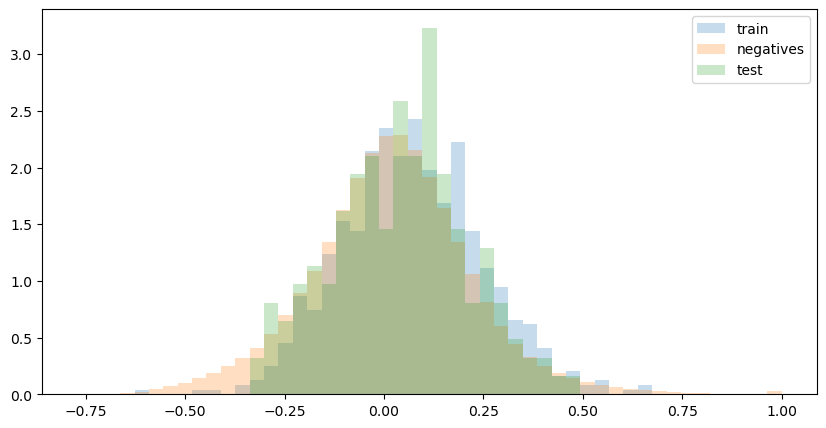

In [15]:
metric = 'r'

_bins = np.linspace(res_cand[metric].min(), res_cand[metric].max(), 50) 

plt.figure(figsize=(10,5)) 
plt.hist(res_cand[lambda x: x.train_edge][metric], bins=_bins, alpha=0.25, label='train', density=True) 
plt.hist(res_cand[lambda x: x.negative][metric], bins=_bins, alpha=0.25, label='negatives', density=True) 
plt.hist(res_cand[lambda x: x.test_edge][metric], bins=_bins, alpha=0.25, label='test', density=True) 
plt.legend() 
plt.show() 